In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
import random
random.seed(42)
random.shuffle(words)

In [6]:
block_size = 8 #context length

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix) #a set of context predicts ix
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:]) 

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [11]:
print(Xtr)
print(Ytr)

tensor([[ 0,  0,  0,  ...,  0,  0,  0],
        [ 0,  0,  0,  ...,  0,  0, 25],
        [ 0,  0,  0,  ...,  0, 25, 21],
        ...,
        [ 0,  0,  0,  ..., 15, 12,  4],
        [ 0,  0,  0,  ..., 12,  4,  1],
        [ 0,  0,  8,  ...,  4,  1, 14]])
tensor([25, 21,  8,  ...,  1, 14,  0])


In [7]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [8]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1): #dim-> num of features being normalized i.e if x.shape is (32,200) then 32 examples, 200 features
    self.eps = eps #eps prevents division by zero, during normalization sqrt(variance + eps) if var is closer to 0 then eps keeps denominator safe
    self.momentum = momentum #controls how quickly the running statistics adapt
    self.training = True #currently training, so use statistics from the current minibatch.
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim) #x->normalize->xhat->gamma * xhat + beta (gamma,beta are learnable params that get optimized through backpropagation)
    self.beta = torch.zeros(dim) #gamma lets the network learn the appropriate scale, beta lets the network learn the appropriate shift.
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim) #not learned during gradient descent, buffers that store long term estimate of distrubtion seen during training. 
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    if self.training:
      if x.ndim == 2:
        dim = 0 #each feature gets independently normalized not 200 together (1,200)
      elif x.ndim == 3: #B-batch, T-Time/Context Posn, C-channels/features => 32,4,200 (each of 200 channel needs to have its own mean & variance, so avging acorss (0,1) mean time and batch dims are treated as observations. Leaving only channel dims. Resulting=> (1,1,200)
        dim = (0,1)
          #calculation=>batch stats=> for each feature/channel BN asks avg activation, how much do activations vary around that avg
      xmean = x.mean(dim, keepdim=True) # batch mean xmean = x.mean((0, 1), keepdim=True) => Each channel gets one normalization statistic.
      xvar = x.var(dim, keepdim=True) # batch variance
        #e.g if one channel across the batch looks like [4, 6, 8, 10] then mean is 7 and var is something repsenting its spread
    else:
        # stop calculating statistics from the current input instead use stored running mean and var => normalize
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim)) #(27, 10)
#     num_embeddings → how many possible discrete tokens exist
# embedding_dim → how many numbers represent each token
  def __call__(self, IX):
    self.out = self.weight[IX] 
    return self.out
  
  def parameters(self):
    return [self.weight]


class FlattenConsecutive: #a custom layer for grouping consecutive time steps together and flattening them into a single feature vector.
  #FlattenConsecutive(2) Take every 2 consecutive characters/features and concatenate them.
  def __init__(self, n):
    self.n = n
    
  def __call__(self, x):
    B, T, C = x.shape
      # x.shape = (32, 8, 10)
      #32 examples
# 8 positions per example
# 10-dimensional embedding at each position
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1) #final layer expects 2D so is 1 then squeze it (batch_size, 1, features) to (batch_size, features)
    self.out = x
    return self.out
#   c1 = [a, b, c]
# c2 = [d, e, f]
    # [c1, c2] → [a, b, c, d, e, f]
  def parameters(self):
    return []


class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
#WaveNet-style architecture instead combines the context gradually and hierarchically.
#major difference from earlier MLP is there I essentially flattened the entire context immediately 
#embcat = emb.view(emb.shape[0], -1)-->
#(B, 8, 10)
# ↓
# (B, 80)

In [12]:
# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True


76579


In [13]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2911
  10000/ 200000: 1.9315
  20000/ 200000: 1.7316
  30000/ 200000: 2.0011
  40000/ 200000: 1.8338
  50000/ 200000: 1.4619
  60000/ 200000: 1.8801
  70000/ 200000: 2.1550
  80000/ 200000: 1.9198
  90000/ 200000: 1.7979
 100000/ 200000: 2.3133
 110000/ 200000: 1.7964
 120000/ 200000: 2.2753
 130000/ 200000: 1.7961
 140000/ 200000: 2.1823
 150000/ 200000: 1.9151
 160000/ 200000: 1.3412
 170000/ 200000: 1.5945
 180000/ 200000: 1.8663
 190000/ 200000: 1.6971


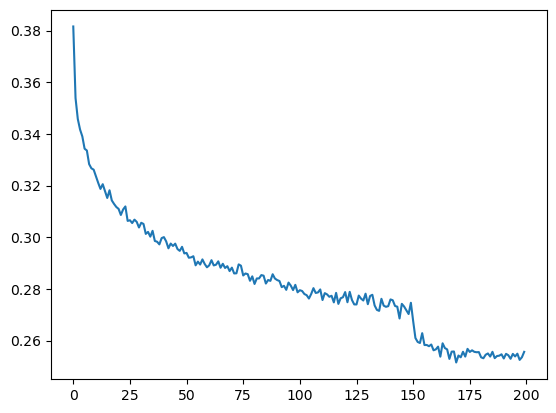

In [14]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))